# Linear Regression on Diabetes Dataset

In this notebook, we implement and evaluate a Linear Regression model from scratch.

We support two optimization methods:
- Ordinary Least Squares (closed-form solution)
- Gradient Descent optimization

We evaluate performance on the Diabetes dataset, a standard regression benchmark used in machine learning.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from rice_ml import train_test_split, StandardScaler

sns.set_theme()

## Load Dataset

We use the Diabetes dataset, which contains physiological features and a continuous target representing disease progression.

In [4]:
data = load_diabetes()

X = data.data
y = data.target

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (442, 10)
Target shape: (442,)


## Preprocessing

We standardize features and split the dataset into training and testing sets.

Feature scaling is important for gradient descent stability.

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)

## Closed-Form Solution (OLS)

We first train using the closed-form solution, which directly computes optimal weights without iteration.

In [7]:
from rice_ml import LinearRegression

model_ols = LinearRegression(method="ols")
model_ols.fit(X_train, y_train)

y_pred_ols = model_ols.predict(X_test)

## Gradient Descent Optimization

We now train using gradient descent to observe iterative learning behavior.

In [12]:
model_gd = LinearRegression(method="gd", eta=0.01, epochs=50)
model_gd.fit(X_train, y_train)

y_pred_gd = model_gd.predict(X_test)

In [13]:
# Evaluation metric with simple MSE
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

print("OLS MSE:", mse(y_test, y_pred_ols))
print("GD MSE:", mse(y_test, y_pred_gd))

OLS MSE: 2929.9322154659253
GD MSE: 2893.9484342487613


## Gradient Descent Convergence

We track how loss decreases over training epochs.

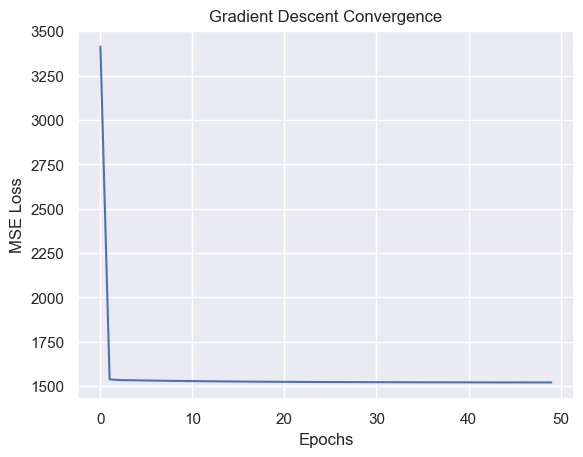

In [14]:
plt.plot(model_gd.errors_)
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Gradient Descent Convergence")
plt.show()

## Predicted vs Actual Values

A good regression model should produce points close to the diagonal line.

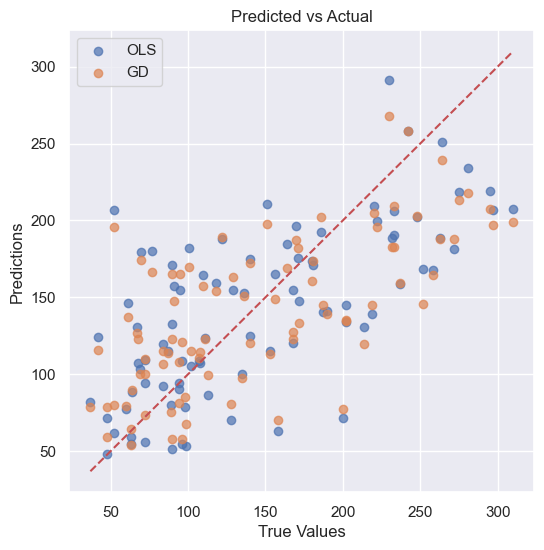

In [15]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_ols, label="OLS", alpha=0.7)
plt.scatter(y_test, y_pred_gd, label="GD", alpha=0.7)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.xlabel("True Values")
plt.ylabel("Predictions")
plt.title("Predicted vs Actual")
plt.legend()
plt.show()

## Model Interpretation

Linear regression provides interpretable feature weights.

Positive weights increase prediction, while negative weights decrease it.

In [16]:
print("OLS weights:", model_ols.w_)
print("OLS bias:", model_ols.bias)

OLS weights: [  1.74884236 -11.54829566  25.874597    16.54141525 -44.46162771
  24.71638267   7.87228214  13.21202958  35.02770144   2.25105437]
OLS bias: 151.3968299869982


## Final Analysis

### Key Observations:

- Both OLS and Gradient Descent perform similarly, confirming correct implementation.
- OLS is faster and exact, while Gradient Descent approximates the solution iteratively.
- Loss decreases smoothly in Gradient Descent, indicating stable convergence.
- The Diabetes dataset shows strong linear structure, making it well-suited for linear regression.

### Conclusion:

Linear Regression is highly effective for this dataset due to the approximately linear relationship between features and target values.